In [14]:
import numpy as np
import matplotlib.pyplot as plt
from gen_catalyst_design.db import Database, load_data_from_db
from ase.io import read,write
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, OneHotEncoder


100
2.4370869217969613


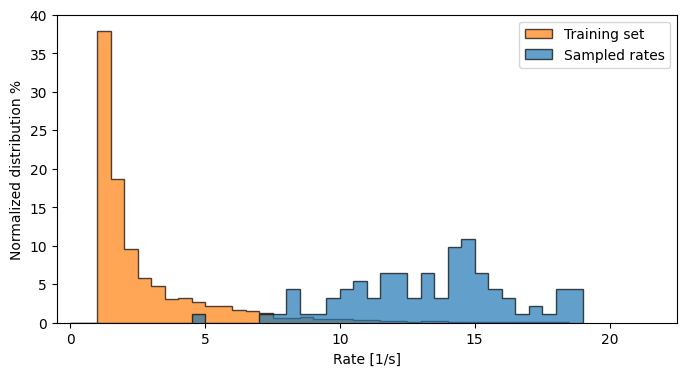

In [31]:
atoms_list = read(filename="../random_search.traj", index=":")
train_datadicts = [{"elements":atoms.get_chemical_symbols(), "rate":atoms.info["rate"]} for atoms in atoms_list]
train_rates = np.array([atoms.info["rate"] for atoms in atoms_list])
element_pool = ["Rh", "Cu", "Pd", "Au"]

model = "5mpl_rand/regular_10_g2"
miller_index = "100"
database = Database.establish_connection(filename="rate_evals_0.5.db", miller_index=miller_index, pth_header=model)
datadicts = load_data_from_db(database=database)
print(len(datadicts))
sampled_rates = np.array([datadict["rate"] for datadict in datadicts])
#sampled_atoms = []
#for iter in [2]:
#    sampled_atoms += read(filename=f"../../active_learning/samples_iter_{iter}.traj", index=":")
#sampled_rates = np.array([atoms.info["rate"] for atoms in sampled_atoms])
#write("tot_act_sampled.traj", sampled_atoms)
print(np.max(sampled_rates)-np.max(train_rates))
fig, ax = plt.subplots(figsize=(8,4))
train_rates#rates = np.array([datadict["rate"] for datadict in datadicts])
rate_interval = 0.5
rate_max = np.max(train_rates)
rate_min = 0.0

i = 0
hist_prior = None
y_lims = 0.40*100
labels = [
    "Training set",
    "Sampled rates"
]

step = 2.5
classes = np.arange(1.0, np.ceil(rate_max)+step, step)#np.linspace(1.0, np.ceil(rate_max), 5)
for rates, color, label in zip([train_rates, sampled_rates], ["C1", "C0"], labels):
    bins = np.arange(rate_min, rate_max, rate_interval)
    hist, edges = np.histogram(rates, bins=bins)
    hist_norm = hist/np.sum(hist)
    ax.stairs(hist_norm*100, edges=edges, fill=True, alpha=0.7, edgecolor="k", linewidth=1, color=color, label=label)
    ax.set_xlim([-0.5, np.ceil(rate_max)+step])
    ax.set_ylim([0.0, y_lims])
    ax.set_ylabel("Normalized distribution %")
    ax.set_xlabel("Rate [1/s]")
ax.legend()

In [26]:
keys_train = ["".join(atoms.get_chemical_symbols()) for atoms in atoms_list]
uniques = []
for data_dict in datadicts:
    elements_str = "".join(data_dict["elements"])
    if elements_str not in keys_train:
        uniques.append(elements_str)

In [27]:
len(uniques)/len(datadicts)

1.0

In [8]:
def element_to_onehot(element, mapping_dict):
    onehot = np.zeros(len(mapping_dict))
    onehot[mapping_dict[element]] +=1
    return onehot

def get_onehots_from_datadict(datadicts, element_pool):
    mapping_dict = {element:i for i, element in enumerate(element_pool)}
    result_onehots = []
    for datadict in datadicts:
        elements = datadict["elements"]
        onehots = np.hstack([element_to_onehot(element=element, mapping_dict=mapping_dict) for element in elements])
        result_onehots.append(onehots)
    return np.vstack(result_onehots)

def assign_classes(datadicts, classes, num_classes):
    class_divs = {}
    for i in range(num_classes):
        for j, datadict in enumerate(datadicts):
            rate = datadict["rate"]
            if rate > classes[i] and rate < classes[i+1]:
                if i in class_divs:
                    class_divs[i].append(j)
                else:
                    class_divs[i] = [j]
    return class_divs

In [11]:
elements_train_data = ["".join(atoms.get_chemical_symbols()) for atoms in atoms_list]
atoms_new = []
atoms_new_str = []
for atoms in sampled_atoms:
    key_str = "".join(atoms.get_chemical_symbols())
    if key_str not in elements_train_data and key_str not in atoms_new_str:
        atoms_new.append(atoms)
        atoms_new_str.append(key_str)

In [13]:
iter_1_atoms_list = read(filename=f"../../active_learning/samples_iter_{1}.traj", index=":")
new_data = elements_train_data + atoms_new_str
atoms_iter_1_new = []
atoms_new_str = []
for atoms in iter_1_atoms_list:
    key_str = "".join(atoms.get_chemical_symbols())
    if key_str not in new_data and key_str not in atoms_new_str:
        atoms_new.append(atoms)
        atoms_new_str.append(key_str)

In [14]:
len(atoms_new_str)/len(iter_1_atoms_list)

0.33444816053511706

NameError: name 'onehots' is not defined

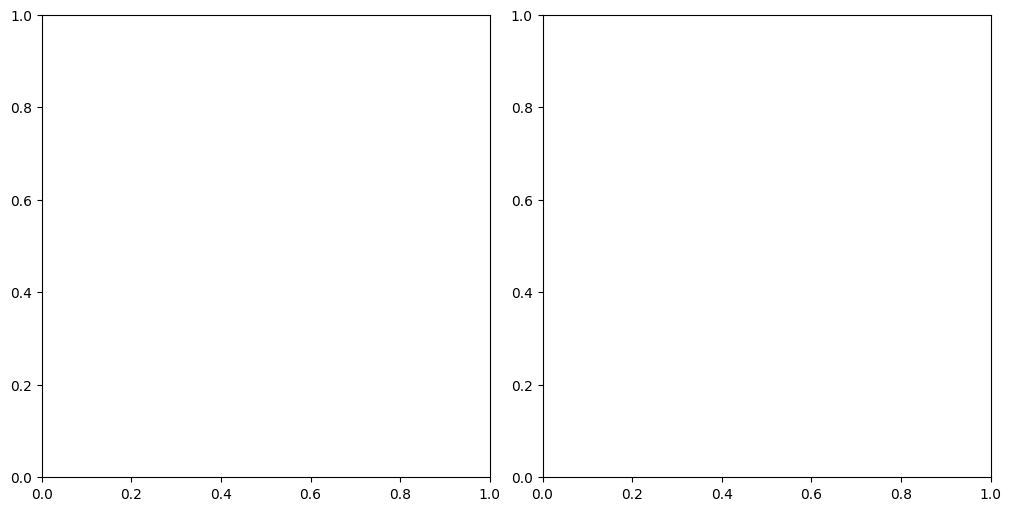

In [15]:
fig, axs = plt.subplots(1,2, figsize=(10,5), layout="constrained")
onehots_tot = np.vstack([onehots, onehots_sampled])
tsne = TSNE(n_components=2, learning_rate='auto', init='random', random_state=42)
transformed_tot = tsne.fit_transform(onehots_tot)
sampled_transformed = transformed_tot[len(onehots):]
transformed = transformed_tot[:len(onehots)]

scatter = axs[0].scatter(transformed[:,0], transformed[:,1], c=train_rates, cmap=cmap, vmin=rate_min, vmax=rate_max, alpha=0.2)
axs[0].scatter(sampled_transformed[:,0], sampled_transformed[:,1], c="C0", alpha=0.2)

axs[1].scatter(transformed[:,0], transformed[:,1], c="C0", alpha=0.2)
scatter = axs[1].scatter(sampled_transformed[:,0], sampled_transformed[:,1], c=sampled_rates, cmap=cmap, vmin=rate_min, vmax=rate_max, alpha=0.2)
plt.colorbar(scatter, label="Rate [1/s]")


In [ ]:
fig, ax = plt.subplots()
ax.set_xlabel("Conditioned rate [1/s]")
ax.set_ylabel("Sampled rate distributions [1/s]")
rates = [5, 8, 10, 12, 15, 18, 20, 23, 25]
temp = 0.5
ax.set_title(f"temperature: T={temp}")
model = "5mpl_no_aux_no_duplicates_no_active_site"
mean_rates_sampled = []
sampled_rates_tot = []
for rate in rates:
    pth_header = f"{model}/regular_{rate}"
    database = Database.establish_connection(filename=f"rate_evals_{temp}.db", miller_index=miller_index, pth_header=pth_header)
    datadicts = load_data_from_db(database=database)
    sampled_rates = np.array([datadict["rate"] for datadict in datadicts])
    sampled_rates_tot.append(sampled_rates)
    mean_rate = np.mean(sampled_rates)
    mean_rates_sampled.append(mean_rate)

line = np.linspace(min(rates)-2, max(rates)+2, 100)
ax.plot(line, line, "--", c="k", lw=1)
ax.scatter(rates, mean_rates_sampled, c="r")
boxplot_dict = ax.boxplot(sampled_rates_tot, positions=rates, widths=1.0, patch_artist=True)
for mean_line in boxplot_dict["medians"]:
    mean_line.set_color("k")
for patch in boxplot_dict["boxes"]:
    #means.set_color("C0")
    patch.set_facecolor("C0")
    patch.set_alpha(0.8)
#plt.draw()
#violin_dict = ax.violinplot(sampled_rates_tot, positions=rates)


In [ ]:
rates = [5, 8, 10, 12, 15, 18, 20, 23, 25]
temp = 0.5
fig, axs = plt.subplots(4, 2, figsize=(12,12), layout="constrained")
#ax.set_xlabel("Conditioned rate [1/s]")
#ax.set_ylabel("Sampled rate distributions [1/s]")
#ax.set_title(f"temperature: T={temp}")
model = "5mpl_no_aux_no_duplicates_no_active_site"
mean_rates_sampled = []
sampled_rates_tot = []
rate_min = 0.0
rate_max = np.max(train_rates)
for rate in rates:
    pth_header = f"{model}/regular_{rate}"
    database = Database.establish_connection(filename=f"rate_evals_{temp}.db", miller_index=miller_index, pth_header=pth_header)
    datadicts = load_data_from_db(database=database)
    sampled_rates = np.array([datadict["rate"] for datadict in datadicts])
    sampled_rates_tot.append(sampled_rates)
    mean_rate = np.mean(sampled_rates)
    mean_rates_sampled.append(mean_rate)

for ax, sampled_rates, rate_cond in zip(axs.flatten(), sampled_rates_tot, rates):
    for rates, color, label in zip([train_rates, sampled_rates], ["C1", "C0"], labels):
        bins = np.arange(rate_min, rate_max, rate_interval)
        hist, edges = np.histogram(rates, bins=bins)
        hist_norm = hist/np.sum(hist)
        ax.stairs(hist_norm*100, edges=edges, fill=True, alpha=0.7, edgecolor="k", linewidth=1, color=color, label=label)
    ax.set_xlim([-0.5, np.ceil(rate_max)+step])
    ax.set_ylim([0.0, y_lims])
    ax.vlines(rate_cond, 0, y_lims, colors="k", ls="--", label=f"rate condition: {rate_cond}")
    ax.set_ylabel("Normalized distribution %")
    ax.set_xlabel("Rate [1/s]")
    ax.legend()

In [ ]:
def get_avg_elem_stats(element_lists, element_pool):
    tot_atom_count = 0
    element_count = {}
    for element in element_pool:
        for element_list in element_lists:
            count = element_list.count(element)
            if element in element_count:
                element_count[element]+=count
            else:
                element_count[element]=count
            tot_atom_count+=count
    for element in element_count:
        element_count[element]/=tot_atom_count
    return element_count

In [ ]:
train_element_lists = [atoms.get_chemical_symbols() for atoms in atoms_list]
train_stats = get_avg_elem_stats(element_lists=train_element_lists, element_pool=element_pool)

sample_element_lists = [datadict["elements"] for datadict in datadicts]
sample_stats = get_avg_elem_stats(element_lists=sample_element_lists, element_pool=element_pool)
print(train_stats)
print(np.array([train_stats[elem] for elem in train_stats]).sum())
print(sample_stats)
print(np.array([sample_stats[elem] for elem in sample_stats]).sum())


In [ ]:
low_rate_indices = np.argwhere(train_rates < np.mean(train_rates)).squeeze()
high_rate_indices = np.argwhere(train_rates > np.mean(train_rates)).squeeze()
print(len(high_rate_indices))
for indices in [low_rate_indices, high_rate_indices]:
    filtered_atoms_list = [atoms_list[index] for index in indices]
    element_lists = [atoms.get_chemical_symbols() for atoms in filtered_atoms_list]
    element_stats = get_avg_elem_stats(element_lists=element_lists, element_pool=element_pool)
    print(element_stats)